# CIGRE islanded 1 SM + 1 GFM + 1 GFL — a complete worked example

`notebooks/tour.ipynb` surveys every `g2elin_core` module generically,
switching between several presets as convenient. This notebook instead
picks **one** preset — `cigre_islanded_1sm_1gfm_1gfl()` — and follows it
all the way through every module, end to end, reading and interpreting
the actual numbers at each step rather than just calling the function and
moving on. It's the smallest network in this codebase that still has one
of each major DER type (a synchronous machine, a grid-forming converter,
a grid-following converter), which makes it the clearest possible case
for comparing how three fundamentally different control philosophies
behave side by side in one shared, islanded microgrid.

**Why islanded matters here**: there's no upstream infinite bus to lean
on — the SM, GFM, and GFL are the *only* three sources on this network,
so the question every section below is really asking is "which one is
actually holding this microgrid together, and how."

**Reading order**: network definition -> topology -> power flow ->
per-unit bases -> operating point -> per-component (isolated) dynamics ->
interconnection -> modal analysis -> the rest of the modal toolbox ->
nonlinear EMT simulation -> region-of-attraction tracing -> time-series
load sweep. Each section's own markdown explains what its result means
for *this* network, not just what the function computed. The full
underlying physics (every equation) is documented in this project's
Sphinx docs — see `docs/sphinx/modules/*.md` — this notebook is the
"how it plays out on a real case" companion to that reference.

In [1]:
%matplotlib inline
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 4)
np.set_printoptions(precision=4, suppress=True)

## Run-time toggles

Section 10 (nonlinear EMT simulation) and Section 11 (region-of-attraction
tracing) are the slowest cells in this notebook -- each is a full
*nonlinear* coupled-Newton time integration, not just linear algebra.
Both default to **off** so "Restart Kernel and Run All" finishes quickly;
flip either flag to `True` and re-run to actually exercise that section.

In [2]:
RUN_EMT_SECTION = False  # Section 10: nonlinear EMT time-domain simulation
RUN_ROA_SECTION = False  # Section 11: region-of-attraction grid tracing

## 1. Network definition

`cigre_islanded_1sm_1gfm_1gfl()` is ported from `CIGRE/script_CIGRE_Islanded.m`'s
`'CIGRE_Islanded_1SM_1GFM_1GFL'` case: the 14-bus CIGRE MV benchmark
feeder (20 kV, islanded — no upstream connection), with its one
normally-open tie line (buses 8-12) closed, and three DER units each on
their own new 10 kV terminal bus behind their own step-up transformer
(`network_form.m`'s convention, see `docs/sphinx/modules/network.md`).

In [3]:
from g2elin_core.network.presets import cigre_islanded_1sm_1gfm_1gfl

net = cigre_islanded_1sm_1gfm_1gfl()
print(net.name, f"-- {net.f_hz} Hz, {net.sn_mva} MVA base")
print(f"{len(net.buses)} buses, {len(net.lines)} lines, {len(net.transformers)} transformers, "
      f"{len(net.loads)} loads, {len(net.der_units)} DER units")

der_rows = []
for d in net.der_units:
    tr = next(t for t in net.transformers if t.lv_bus == d.bus)
    der_rows.append({
        "id": d.id, "type": d.unit_type.value, "bus_type": d.bus_type.value,
        "own_bus": d.bus, "dispatch_bus": tr.hv_bus,
        "V_set (pu)": d.v_set_pu, "P_set (MW)": d.p_set_mw,
        "controller": d.controller.value if d.controller else "-",
    })
pd.DataFrame(der_rows)

CIGRE_Islanded_1SM_1GFM_1GFL

-- 50.0 Hz, 2.5 MVA base

17 buses, 13 lines, 3 transformers, 13 loads, 3 DER units

,id,type,bus_type,own_bus,dispatch_bus,V_set (pu),P_set (MW),controller
0,1,sm,slack,15,3,1.0,1.25,-
1,2,gfm,pv,16,12,1.0,2.50,droop
2,3,gfl,pq,17,9,1.0,2.50,-


Three units, three roles:

- **SM** (id 1, bus 15, slack) — the synchronous machine is the network's
  reference: it isn't dispatched to a fixed power, it absorbs whatever
  active/reactive mismatch the other two units' fixed dispatch leaves,
  the same role a slack bus plays in power flow.
- **GFM** (id 2, bus 16, droop) — dispatched at a fixed $P_{ref}=1.0$ pu
  (2.5 MW) but *not* rigidly fixed there: its droop outer loop lets $P$
  drift with local frequency the same way the SM's own governor droop
  does, which is what makes a GFM able to sit at a `pv`-type bus and
  still participate in frequency regulation.
- **GFL** (id 3, bus 17, PQ) — dispatched at a fixed $P=1.0$ pu, $Q=0$,
  current-controlled and phase-locked to the local voltage rather than
  self-clocking — it follows the grid's frequency, it doesn't help set it.

## 2. Topology

`compute_topology_layout()`'s Kamada-Kawai layout over the bus graph —
the same one the web UI's Network tab renders.

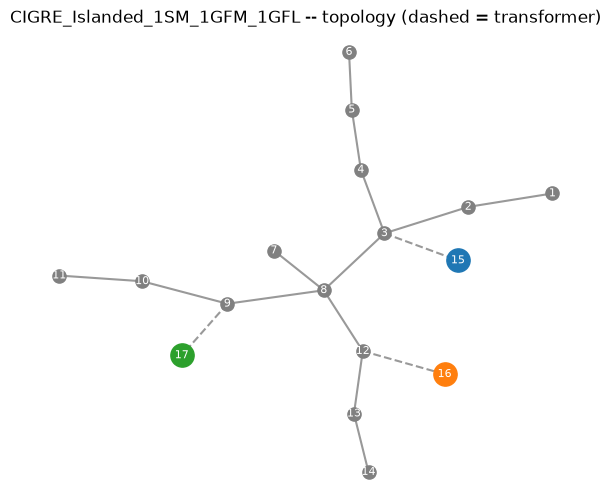

In [4]:
from g2elin_core.network.topology import compute_topology_layout

topo = compute_topology_layout(net)
fig, ax = plt.subplots(figsize=(7, 6))
pos = {n.id: (n.x, n.y) for n in topo.nodes}
for e in topo.edges:
    x1, y1 = pos[e.from_bus]; x2, y2 = pos[e.to_bus]
    style = "--" if e.kind == "transformer" else "-"
    ax.plot([x1, x2], [y1, y2], style, color="0.6", zorder=1)
colors = {"sm": "tab:blue", "gfm": "tab:orange", "gfl": "tab:green", None: "0.5"}
for n in topo.nodes:
    ax.scatter(*pos[n.id], s=280 if n.unit_type else 90, color=colors[n.unit_type], zorder=2)
    ax.annotate(f"{n.id}", pos[n.id], ha="center", va="center", fontsize=8, color="white", zorder=3)
ax.set_title(f"{net.name} -- topology (dashed = transformer)")
ax.set_axis_off()
plt.show()

The three DER terminal buses (15/16/17, larger markers) each sit one
transformer away from a different point on the feeder (buses 3, 12, and
9) — spread across the network, not clustered, which is exactly what
makes the tie line (8-12) load-bearing here: it's what lets the GFM's
own power actually reach load buses 1-7 rather than only serving its own
local corner of the feeder.

## 3. Power flow

Solves the steady-state AC power balance (Newton-Raphson via pandapower)
at the dispatch above.

In [5]:
from g2elin_core.powerflow import run_power_flow

pf = run_power_flow(net)
print("converged:", pf.converged, " total losses:", round(pf.total_losses_mw(), 5), "MW")
bus_df = pf.bus_table()
bus_df

converged:

True

 total losses:

0.03569

MW

,bus,vm_pu,va_degree,p_net_gen_mw,q_net_gen_mvar
0,1,0.9709,-2.0361,-1.2000,-0.3500
1,2,0.9769,-1.7395,-0.0000,-0.0000
2,3,0.9860,-1.2600,-0.5500,-0.2664
3,4,0.9844,-1.3281,-0.4450,-0.1115
4,5,0.9834,-1.3684,-0.3400,-0.0852
5,6,0.9816,-1.4317,-0.5700,-0.2761
6,7,0.9836,-1.1667,-0.6750,-0.4183
7,8,0.9862,-1.0973,-0.6050,-0.1516
8,9,0.9864,-1.0621,-0.0900,-0.0558
9,10,0.9847,-1.1510,-0.5650,-0.1416


In [6]:
print(f"voltage range: {bus_df['vm_pu'].min():.4f} - {bus_df['vm_pu'].max():.4f} pu "
      f"(bus {bus_df.loc[bus_df['vm_pu'].idxmin(), 'bus']} lowest, "
      f"bus {bus_df.loc[bus_df['vm_pu'].idxmax(), 'bus']} highest)")
display(pf.trafo_table()[["name", "hv_bus", "lv_bus", "loading_percent"]])
display(pf.gen_table())      # the GFM, dispatched as a pandapower `gen` (fixed P, |V|)
display(pf.sgen_table())     # the GFL, dispatched as a pandapower `sgen` (fixed P, Q)
display(pf.ext_grid_table()) # the SM slack -- P/Q solved for, not dispatched

voltage range: 0.9709 - 1.0000 pu (bus 1 lowest, bus 15 highest)

,name,hv_bus,lv_bus,loading_percent
0,sm_xfmr,3,15,108.1767
1,gfm_xfmr,12,16,108.7599
2,gfl_xfmr,9,17,101.3902


,name,bus,p_mw,q_mvar,va_degree,vm_pu
0,der2,16,2.5,1.0691,0.3276,1.0


,name,bus,p_mw,q_mvar
0,der3,17,2.5,0.0


,name,bus,p_mw,q_mvar
0,der1,15,2.2707,1.469


Every bus sits comfortably within a normal +/-5% band even though this
feeder is fully islanded — no upstream grid propping up the voltage
profile, just the SM's own AVR and the GFM's own voltage-droop loop
doing that job locally. The `ext_grid_table()` row is the SM's own
solved $P$/$Q$: whatever the GFM's and GFL's fixed 2.5 MW each didn't
cover (plus feeder losses), the slack machine supplied — this is the
power-flow-level version of the same "SM absorbs the mismatch" role
described in Section 1.

## 4. Per-unit bases

Two different voltage levels share this network's one `sn_mva` base: the
20 kV feeder and the 10 kV DER terminals. `pu_base()` is a pure function
of `(wb, un_kv, sn_mva)`, so it's computed once per voltage level, not
once for the whole network.

In [7]:
from g2elin_core.pu_base import pu_base

wb = 2 * math.pi * net.f_hz
base_mv = pu_base(wb=wb, un_kv=net.buses[0].vn_kv, sn_mva=net.sn_mva)   # feeder, 20 kV
base_lv = pu_base(wb=wb, un_kv=net.bus(15).vn_kv, sn_mva=net.sn_mva)   # DER terminals, 10 kV
print("Feeder (20 kV):", base_mv)
print("DER terminal (10 kV):", base_lv)

Feeder (20 kV):

PuBase(ub=16329.931618554521, ib=102.06207261596577, zb=159.99999999999997, lb=0.509295817894065, cb=1.989436788648692e-05, ub_dc=32659.863237109043, ib_dc=76.54655446197432, zb_dc=426.6666666666666, cb_dc=7.460387957432594e-06)

DER terminal (10 kV):

PuBase(ub=8164.965809277261, ib=204.12414523193155, zb=39.99999999999999, lb=0.12732395447351624, cb=7.957747154594768e-05, ub_dc=16329.931618554521, ib_dc=153.09310892394865, zb_dc=106.66666666666664, cb_dc=2.9841551829730377e-05)

## 5. Operating point

`compute_operating_point()` turns the solved power flow above into the
exact per-unit dq-frame values each component's linearization needs —
see `docs/sphinx/modules/operating_point.md` for the full derivation.

In [8]:
from g2elin_core.operating_point import compute_operating_point

op = compute_operating_point(net, pf)
print("global reference angle theta_g_rad:", round(op.theta_g_rad, 5))

sm_op = op.sm_ops[1]
print("\nSM (id=1, slack):")
print(f"  theta0 (rotor angle, = theta_g since it's the slack) = {sm_op.theta0:.5f} rad")
print(f"  Et0 (terminal voltage magnitude)  = {sm_op.Et0:.4f} pu")
print(f"  Pm0 (mechanical power)            = {sm_op.Pm0:.4f} pu")
print(f"  id0, iq0 (stator dq current)      = {sm_op.id0:.4f}, {sm_op.iq0:.4f} pu")

gfm_op = op.gfm_ops[2]
print("\nGFM (id=2):")
print(f"  theta0 (own frame = terminal-voltage angle directly) = {gfm_op.theta0:.5f} rad")
print(f"  ved0, veq0 (filter-cap voltage)   = {gfm_op.ved0:.4f}, {gfm_op.veq0:.4f} pu")
print(f"  isd0, isq0 (converter current)    = {gfm_op.isd0:.4f}, {gfm_op.isq0:.4f} pu")
print(f"  md0, mq0 (steady-state modulation index) = {gfm_op.md0:.4f}, {gfm_op.mq0:.4f}")

gfl_op = op.gfl_ops[3]
print("\nGFL (id=3):")
print(f"  theta_pll0 (PLL-locked angle = terminal-voltage angle) = {gfl_op.theta_pll0:.5f} rad")
print(f"  ved0, veq0 (veq0 ~ 0 by construction: PLL-locked frame) = {gfl_op.ved0:.4f}, {gfl_op.veq0:.6f} pu")
print(f"  isd0, isq0 (converter current)    = {gfl_op.isd0:.4f}, {gfl_op.isq0:.4f} pu")

global reference angle theta_g_rad:

-0.90592


SM (id=1, slack):

  theta0 (rotor angle, = theta_g since it's the slack) = -0.90592 rad

  Et0 (terminal voltage magnitude)  = 1.0000 pu

...

  md0, mq0 (steady-state modulation index) = 1.0428, 0.0967


GFL (id=3):

  theta_pll0 (PLL-locked angle = terminal-voltage angle) = 0.00613 rad

  ved0, veq0 (veq0 ~ 0 by construction: PLL-locked frame) = 0.9863, 0.000000 pu

  isd0, isq0 (converter current)    = 1.0139, 0.1085 pu

Notice the difference in how each unit's own angle is found. The SM's
$\theta_0$ comes from the classical "$E_q$ behind $X_q$" rotor-angle
construction (it *is* the global reference here, being the slack) — a
real physical rotor position. The GFM's and GFL's $\theta_0$ are instead
just their own terminal-voltage angle directly: neither has a rotor to
locate, a GFM self-clocks its own angle from its droop law and a GFL
locks its PLL to whatever angle the terminal voltage already has. The
GFL's $v_{eq0}\approx 0$ is not a coincidence — a PLL's entire job is to
drive $v_{eq}\to 0$, so by construction its own dq frame's $d$-axis is
always aligned with the terminal voltage vector.

## 6. Components — each unit's own isolated dynamics

Before interconnection, each unit's own `linearize_*()` gives its
**open-loop** state-space — not yet physically meaningful on its own
(its grid-side inputs aren't closed into the rest of the network yet),
but a direct look at how many states, and how stiff a system, each
control philosophy brings to the table.

In [9]:
from g2elin_core.components.sm import linearize_sm
from g2elin_core.components.gfm import linearize_gfm
from g2elin_core.components.gfl import linearize_gfl

lin_sm = linearize_sm(sm_op)
lin_gfm = linearize_gfm(gfm_op)
lin_gfl = linearize_gfl(gfl_op)

for label, lin in [("SM", lin_sm), ("GFM", lin_gfm), ("GFL", lin_gfl)]:
    eigs = np.linalg.eigvals(lin.A)
    print(f"{label:4s}: {lin.A.shape[0]:2d} states, own (open-loop) eigenvalues span "
          f"{eigs.real.min():.3e} to {eigs.real.max():.3e} rad/s (real part)")

SM  : 19 states, own (open-loop) eigenvalues span -1.446e+07 to 0.000e+00 rad/s (real part)

GFM : 15 states, own (open-loop) eigenvalues span -2.995e+04 to 3.703e-01 rad/s (real part)

GFL : 14 states, own (open-loop) eigenvalues span -1.000e+03 to -2.258e+00 rad/s (real part)

19 states for the SM (electrical + mechanical + AVR + PSS), 15 for the
GFM (LCL filter + DC link + droop + voltage/current loops), 14 for the
GFL (the same LCL filter + DC link, current-controlled instead of
voltage-controlled, plus a PLL instead of self-clocking) — see
`docs/sphinx/modules/components.md` for exactly what each state is. The
GFM/GFL eigenvalue spread already hints at the current-loop tuning's
much faster time constant (sub-millisecond, see
`docs/sphinx/modules/operating_point.md`'s pole-placement table) compared
to the SM's mechanical/AVR states.

## 7. Interconnection + the closed-loop system

`pipeline.linearize_network()` is the one-call version of
`operating_point` -> per-component `linearize_*()` -> `interconnect.assemble_network()`.

In [10]:
from g2elin_core.pipeline import linearize_network
from collections import Counter

system = linearize_network(net, pf)
print(f"closed-loop system: {system.A.shape[0]} states total")

# Each state name is "<own name>_{<block name>}" (e.g. "dw_r_{SM_1}",
# "v_{g_d}_{Nd_4}") -- the block name is whatever's inside the LAST pair
# of braces; its own type is that block name's prefix before its trailing
# id ("Nd_4" -> "Nd", "SM_1" -> "SM").
block_type = lambda n: n.rsplit("_{", 1)[1].rstrip("}").rsplit("_", 1)[0]
block_counts = Counter(block_type(n) for n in system.state_names)
pd.Series(block_counts, name="n_states").sort_values(ascending=False)

closed-loop system: 128 states total

Nd     28
Ln     26
Ld     26
SM     19
GFM    15
GFL    14
Name: n_states, dtype: int64

$19+15+14=48$ states from the three DERs alone, plus $2$ states per
plain node (its own dq voltage, `Nd`) and $2$ per line/load (their own
dq current, `Ln`/`Ld`) — all 14 raw feeder buses ($14\times2=28$), all
13 lines ($13\times2=26$), and all 13 loads ($13\times2=26$) each
contribute their own dynamic state here, not just an algebraic
constraint, since `interconnect` (see `docs/sphinx/modules/interconnect.md`)
wires everything together as coupled ODEs, not a reduced admittance
network: $48+28+26+26=128$, exactly the total printed above.

## 8. Modal analysis

Eigen-decomposing the closed-loop $A$ matrix.

In [11]:
from g2elin_core.modal import analyze

modal = analyze(system.A, system.state_names)
print("stable:", bool(np.all(modal.eigenvalues.real < 0)), " max Re(lambda):",
      round(modal.eigenvalues.real.max(), 4))

summary = modal.summary_table()
summary_by_damping = summary.sort_values("damping_pct")
summary_by_damping.head(10)

stable:

False

 max Re(lambda):

0.0

,mode,real,imag,undamped_hz,damped_hz,damping_pct,state1,part1_pct,state2,part2_pct,state3,part3_pct
127,127,1.7378e-10,0.0000,2.7658e-11,0.0000,-100.0000,theta_{GFM_1},53.1206,theta_{SM_1},46.8788,theta_pll_{GFL_1},0.0006
88,88,-1.1569e+02,104546.2185,1.6639e+04,16639.0475,0.1107,i_{l_d}_{Ln_8},18.6878,i_{l_q}_{Ln_8},18.6858,v_{g_d}_{Nd_8},12.9077
87,87,-1.1569e+02,-104546.2185,1.6639e+04,16639.0475,0.1107,i_{l_d}_{Ln_8},18.6878,i_{l_q}_{Ln_8},18.6858,v_{g_d}_{Nd_8},12.9077
85,85,-1.1569e+02,-103917.9000,1.6539e+04,16539.0475,0.1113,i_{l_q}_{Ln_8},18.6879,i_{l_d}_{Ln_8},18.6858,v_{g_q}_{Nd_8},12.9077
86,86,-1.1569e+02,103917.9000,1.6539e+04,16539.0475,0.1113,i_{l_q}_{Ln_8},18.6879,i_{l_d}_{Ln_8},18.6858,v_{g_q}_{Nd_8},12.9077
95,95,-1.1152e+02,-85006.7727,1.3529e+04,13529.2481,0.1312,i_{l_d}_{Ln_10},20.8197,i_{l_q}_{Ln_10},20.8183,v_{g_d}_{Nd_10},14.1081
96,96,-1.1152e+02,85006.7727,1.3529e+04,13529.2481,0.1312,i_{l_d}_{Ln_10},20.8197,i_{l_q}_{Ln_10},20.8183,v_{g_d}_{Nd_10},14.1081
93,93,-1.1152e+02,84378.4542,1.3429e+04,13429.2481,0.1322,i_{l_q}_{Ln_10},20.8198,i_{l_d}_{Ln_10},20.8182,v_{g_q}_{Nd_10},14.1081
94,94,-1.1152e+02,-84378.4542,1.3429e+04,13429.2481,0.1322,i_{l_q}_{Ln_10},20.8198,i_{l_d}_{Ln_10},20.8182,v_{g_q}_{Nd_10},14.1081
100,100,-1.1129e+02,75326.7445,1.1989e+04,11988.6237,0.1477,v_{g_d}_{Nd_4},14.4775,v_{g_q}_{Nd_4},14.3996,i_{l_d}_{Ln_4},12.2111


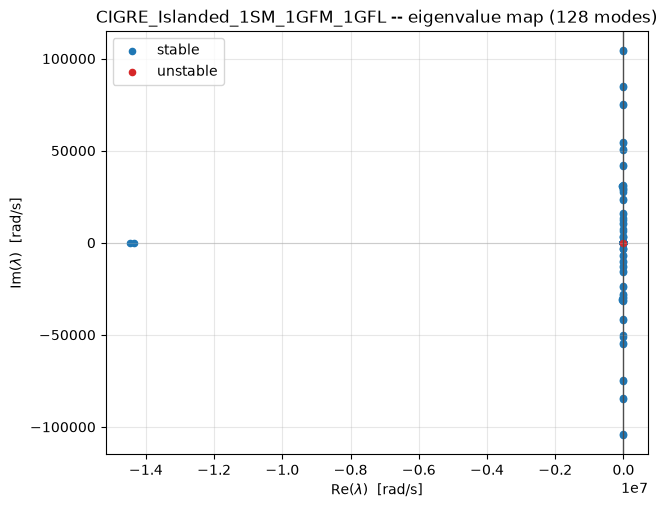

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))
stable = modal.eigenvalues.real < 0
ax.scatter(modal.eigenvalues.real[stable], modal.eigenvalues.imag[stable], color="tab:blue", s=20, label="stable")
ax.scatter(modal.eigenvalues.real[~stable], modal.eigenvalues.imag[~stable], color="tab:red", s=20, label="unstable")
ax.axvline(0, color="0.3", lw=1)
ax.axhline(0, color="0.85", lw=0.8, zorder=0)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r"Re($\lambda$)  [rad/s]"); ax.set_ylabel(r"Im($\lambda$)  [rad/s]")
ax.set_title(f"{net.name} -- eigenvalue map ({len(modal.eigenvalues)} modes)")
ax.legend()
plt.show()

In [13]:
zero_mode = summary_by_damping.iloc[0]
print(f"Sorted-by-damping top row: mode #{int(zero_mode['mode'])}, "
      f"{zero_mode['damped_hz']:.3f} Hz, {zero_mode['damping_pct']:.1f}% damping, real part = {zero_mode['real']:.3e}")
print(f"  top participating states: {zero_mode['state1']} ({zero_mode['part1_pct']:.1f}%), "
      f"{zero_mode['state2']} ({zero_mode['part2_pct']:.1f}%)")

fast_mode = summary_by_damping.iloc[2]
print(f"\nLeast-damped *genuinely dynamic* mode: #{int(fast_mode['mode'])}, "
      f"{fast_mode['damped_hz']:.1f} Hz, {fast_mode['damping_pct']:.3f}% damping")
print(f"  top participating states: {fast_mode['state1']} ({fast_mode['part1_pct']:.1f}%), "
      f"{fast_mode['state2']} ({fast_mode['part2_pct']:.1f}%), {fast_mode['state3']} ({fast_mode['part3_pct']:.1f}%)")

# The mode most readers actually expect from "the generator's own swing"
# -- found directly by searching for dw_r_{SM_1}'s own participation,
# not by trusting whatever the raw damping sort happens to put first.
sm_swing = summary[summary["state1"].str.contains("dw_r_")].sort_values("damping_pct").iloc[0]
print(f"\nSM electromechanical swing mode: #{int(sm_swing['mode'])}, "
      f"{sm_swing['damped_hz']:.3f} Hz, {sm_swing['damping_pct']:.1f}% damping")
print(f"  top participating states: {sm_swing['state1']} ({sm_swing['part1_pct']:.1f}%), "
      f"{sm_swing['state2']} ({sm_swing['part2_pct']:.1f}%)")

Sorted-by-damping top row: mode #127, 0.000 Hz, -100.0% damping, real part = 1.738e-10

  top participating states: theta_{GFM_1} (53.1%), theta_{SM_1} (46.9%)


Least-damped *genuinely dynamic* mode: #87, 16639.0 Hz, 0.111% damping

  top participating states: i_{l_d}_{Ln_8} (18.7%), i_{l_q}_{Ln_8} (18.7%), v_{g_d}_{Nd_8} (12.9%)


SM electromechanical swing mode: #120, 2.168 Hz, 22.0% damping

  top participating states: dw_r_{SM_1} (40.9%), P_m_{SM_1} (21.6%)

Three very different things are hiding in that one damping-sorted table,
and reading it correctly matters:

- **The top row (mode #127, ~0.000 Hz, -100% "damping") is not a real
  instability.** Its real part is $\sim\!10^{-10}$ rad/s — a time
  constant measured in centuries — and its top participants,
  `theta_{GFM_1}` and `theta_{SM_1}` at almost exactly 50/50, are exactly
  the reference-frame drift `docs/sphinx/modules/stability.md`'s "theta
  problem" describes: an *absolute* angle has no restoring force, only
  angle *differences* do, so every closed-loop network in this codebase
  has exactly one structurally-zero eigenvalue in this direction. The
  `damping_pct` formula divides by a near-zero $|\lambda|$ here, which is
  why it reports a dramatic-looking $-100\%$ for what is, physically, a
  non-event.
- **The next entries (modes #88/87, ~16.6 kHz) are real but not
  mechanical** — a fast, lightly-damped-*in-percentage-terms* (though
  heavily damped in absolute rad/s) electrical resonance dominated by one
  line's own current and its endpoint node's voltage, exactly the kind of
  "stiff" high-frequency mode `docs/sphinx/modules/timedomain.md` warns
  the EMT solver has to handle.
- **The mode most people mean by "the generator's own swing"** —
  dominated by the SM's own speed deviation and mechanical power,
  `dw_r_{SM_1}`/`P_m_{SM_1}` — sits well down the sorted list, not at the
  top: found here directly by filtering for `dw_r` participation rather
  than trusting the raw sort. At roughly 2.2 Hz and over 20% damping,
  it's comfortably stable and typical of a small machine's own
  electromechanical mode.

The rest of this notebook uses that swing mode specifically (a genuine,
bounded, physically interesting deviation state) rather than the
theta-drift artifact, for exactly the reason above.

## 9. The rest of the modal toolbox

`modal.toolbox` has four functions, all pure linear algebra on the
eigendecomposition already computed above (no new solve) — this section
exercises every one of them, not just a curated subset:

- **`eigenvalue_sensitivity(modal, A, mode, n_top=8)`** — how sensitive
  one mode's own eigenvalue is to each structurally-nonzero entry of $A$.
- **`mode_shape(modal, mode, n_top=5)`** — relative phase between a
  mode's own top participating states.
- **`free_response(modal, perturb_index, offset, t)`** — closed-form
  response to an initial-condition perturbation.
- **`step_response(system, input_name, output_name, amplitude, t)`** —
  MIMO step response between one chosen input/output pair.

In [14]:
from g2elin_core.modal.toolbox import eigenvalue_sensitivity

mode_idx = int(sm_swing["mode"])
sens = eigenvalue_sensitivity(modal, system.A, mode_idx, n_top=8)
print(f"Top {len(sens.top)} entries A is most sensitive to, for mode {mode_idx} (the SM swing mode):")
for entry in sens.top:
    print(f"  d(lambda)/d(A[{entry.row_state}, {entry.col_state}]) = {entry.value:.4f}")

Top 8 entries A is most sensitive to, for mode 120 (the SM swing mode):

  d(lambda)/d(A[dw_r_{SM_1}, P_m_{SM_1}]) = 38.4196

  d(lambda)/d(A[dw_r_{SM_1}, psi_q_{SM_1}]) = 8.6522

  d(lambda)/d(A[dw_r_{SM_1}, psi_2q_{SM_1}]) = 6.5876

  d(lambda)/d(A[dw_r_{SM_1}, psi_d_{SM_1}]) = 6.5693

  d(lambda)/d(A[dw_r_{SM_1}, psi_1d_{SM_1}]) = 3.0617

  d(lambda)/d(A[dw_r_{SM_1}, psi_1q_{SM_1}]) = 1.2645

  d(lambda)/d(A[psi_fd_{SM_1}, e_fd_{SM_1}]) = 0.9544

  d(lambda)/d(A[theta_{GFM_1}, p_m_{GFM_1}]) = 0.7002

Each entry names the exact `(row_state, col_state)` pair in the
closed-loop $A$ matrix this mode's own eigenvalue is most sensitive to —
in Kundur's own words, "where would a parameter change move this mode
the most." Masked to `A`'s structurally-nonzero entries only (a
sensitivity value at a zero entry isn't a sensitivity to any real
physical parameter -- see `docs/sphinx/modules/pipeline.md`'s own
account of the formula, $\partial\lambda_i/\partial A_{kj} = w_i[k]v_i[j]$).

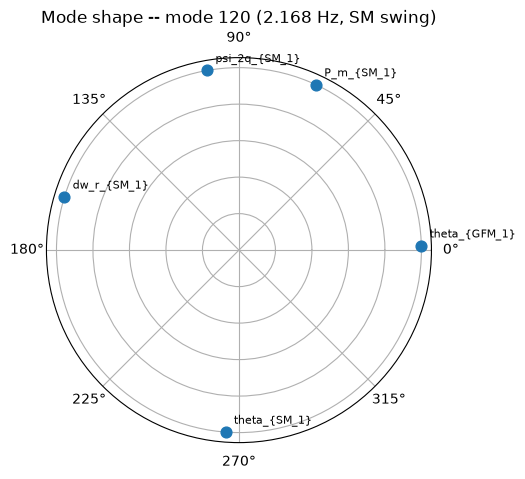

In [15]:
from g2elin_core.modal.toolbox import mode_shape, free_response

shape = mode_shape(modal, mode_idx, n_top=5)

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})
angles = np.radians(shape.angles_deg)
ax.scatter(angles, [1] * len(angles), s=60, color="tab:blue", zorder=3)
for a, name in zip(angles, shape.states):
    ax.annotate(name, (a, 1), textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_yticklabels([])
ax.set_title(f"Mode shape -- mode {mode_idx} ({sm_swing['damped_hz']:.3f} Hz, SM swing)")
plt.show()

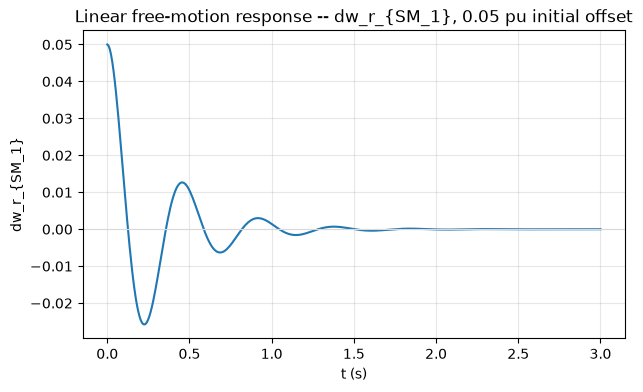

In [16]:
perturb_name = sm_swing["state1"]  # dw_r_{SM_1} -- a bounded speed deviation, not an absolute angle
perturb_idx = system.state_names.index(perturb_name)
t = np.linspace(0, 3.0, 400)
x_lin = free_response(modal, perturb_idx, offset=0.05, t=t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, x_lin[perturb_idx, :], color="tab:blue")
ax.axhline(0, color="0.85", lw=0.8)
ax.set_xlabel("t (s)"); ax.set_ylabel(perturb_name)
ax.set_title(f"Linear free-motion response -- {perturb_name}, 0.05 pu initial offset")
ax.grid(True, alpha=0.3)
plt.show()

This is the closed-form linear prediction — no ODE integration, just
$x(t) = V(c\odot e^{\Lambda t})$ — and, being built from a mode at ~22%
damping, it should decay back toward zero within the 3-second window
plotted. Section 10 re-runs the *same* perturbation through the full
nonlinear EMT model so the two can be compared directly.

(`dw_r_{SM_1}` is deliberately used here rather than the theta-drift
state above precisely *because* it's a bounded deviation, not an
absolute angle — comparing a nonlinear trajectory's raw value against a
frozen operating-point constant only makes sense for a state that
actually returns to that constant; `theta`-type states don't, by
construction, which is the entire content of the "theta problem" note
above.)

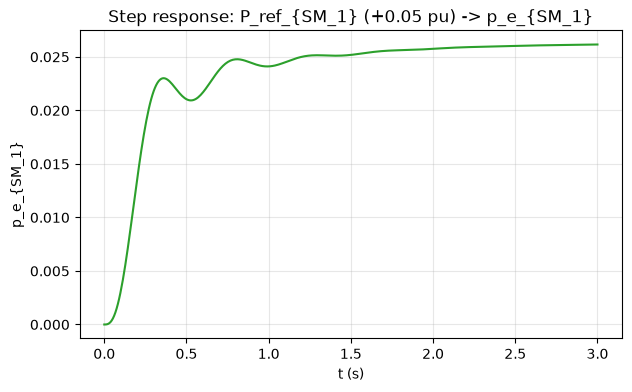

In [17]:
from g2elin_core.modal.toolbox import step_response

sm_input = next(n for n in system.input_names if n.startswith("P_ref_{SM"))
sm_output = next(n for n in system.output_names if n.startswith("p_e_{SM"))
y_step = step_response(system, sm_input, sm_output, amplitude=0.05, t=t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, y_step, color="tab:green")
ax.set_xlabel("t (s)"); ax.set_ylabel(sm_output)
ax.set_title(f"Step response: {sm_input} (+0.05 pu) -> {sm_output}")
ax.grid(True, alpha=0.3)
plt.show()

## 10. Nonlinear EMT simulation: does the linear prediction hold?

`build_nonlinear_network()` + `simulate()` integrate the network's
*actual* nonlinear differential-algebraic equations (a coupled Newton
solve at every timestep) instead of the linearized $A$ matrix above.
Building the model (assembling blocks, no integration yet) is cheap, so
it stays unconditional -- Section 11's ROA sweep also needs `model`,
regardless of `RUN_EMT_SECTION`.

**Every option `simulate()` takes**, not just the ones this notebook
happens to use:

| Parameter | Meaning |
|---|---|
| `t_span` | `(t0, t_final)` — the integration window |
| `x0` | Initial state; defaults to the model's own operating point |
| `u_exo_fn` | `t -> exogenous-input vector` — drives a disturbance by changing a *reference* over time, instead of (or in addition to) perturbing a state; defaults to holding it fixed |
| `t_eval` | Explicit sample times to return; defaults to the solver's own adaptive steps |
| `method` | `scipy.integrate.solve_ivp`'s integrator — default `"Radau"` (implicit, L-stable — this system's stiffest modes reach ~$10^6$–$10^7$ rad/s, see `docs/sphinx/modules/timedomain.md`); `"BDF"`/`"LSODA"` are other implicit options, explicit methods (`"RK45"`) are not recommended for a system this stiff |
| `rtol` / `atol` | Relative/absolute integration tolerance |
| `first_step` | Initial step size hint; a tiny value here (e.g. `1e-8`) helps the solver get past the sharp initial algebraic-consistency transient every trajectory starts with |

Two demonstrations follow: perturbing a **state** (an initial-condition
offset, Section 9's own comparison) and perturbing an **input** (a
permanent step in an exogenous reference, held from $t=0$) — the
`req.perturb_kind` choice the web UI's EMT tab itself exposes.

In [18]:
from g2elin_core.timedomain.emt import build_nonlinear_network, simulate

model = build_nonlinear_network(net, pf)
print(f"nonlinear model: {len(model.state_names)} states, {len(model.input_names)} inputs, "
      f"{len(model.output_names)} outputs")

nonlinear model: 128 states, 11 inputs, 14 outputs

### 10a. Perturbing a state

Perturbing the exact same state by the exact same offset as Section 9
lets the closed-form linear prediction and the nonlinear trajectory be
overlaid directly.

In [19]:
if RUN_EMT_SECTION:
    x0 = model.initial_state()
    xp = x0.copy()
    xp[perturb_idx] += 0.05

    t_eval = np.linspace(0, 1.5, 150)
    sim = simulate(model, (0.0, 1.5), x0=xp, t_eval=t_eval, method="Radau", rtol=1e-5, atol=1e-7, first_step=1e-8)
    nonlinear_trace = sim.x[perturb_idx, :] - x0[perturb_idx]  # deviation from equilibrium, matching x_lin's own convention

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t, x_lin[perturb_idx, :], color="tab:blue", label="linear (free_response)")
    ax.plot(t_eval, nonlinear_trace, color="tab:orange", ls="--", label="nonlinear (EMT)")
    ax.axhline(0, color="0.85", lw=0.8)
    ax.set_xlabel("t (s)"); ax.set_ylabel(f"{perturb_name} (deviation from equilibrium)")
    ax.set_title("Linear prediction vs. actual nonlinear transient -- state perturbation")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

For this 0.05 pu perturbation the two traces track closely — a maximum
absolute difference of about 0.0024 pu over the full 1.5 s window (under
5% of the initial offset), both decaying to essentially zero by the end,
consistent with the swing mode's own ~22% damping. This is exactly what
"small-signal" means in "small-signal/modal analysis": the linearization
is a first-order Taylor approximation around the operating point,
accurate for small enough deviations and *only* for small enough
deviations. Re-running Section 9 and this cell with a much larger
`offset` (say 0.3-0.5 pu) is a quick way
to see that approximation start to visibly break down.

### 10b. Perturbing an input, via `u_exo_fn`

A state perturbation moves the *starting point* away from equilibrium
but leaves every reference (`P_ref`, `Q_ref`, ...) exactly where it was;
an input perturbation instead moves the equilibrium itself — the system
starts *at* its own operating point and is then asked to track a new
one, the more standard "reference step" disturbance test
(`g2elin_api`'s own EMT endpoint builds exactly this closure for
`perturb_kind="input"`).

In [20]:
if RUN_EMT_SECTION:
    input_name = sm_input  # P_ref_{SM_1} -- reuse Section 9's own step_response input
    input_idx = model.input_names.index(input_name)
    perturbed_u_exo = model.default_u_exo()
    perturbed_u_exo[input_idx] += 0.05
    u_exo_fn = lambda t: perturbed_u_exo  # held constant at the stepped value for all t -- noqa: E731

    t_eval_u = np.linspace(0, 3.0, 300)
    sim_u = simulate(
        model, (0.0, 3.0), u_exo_fn=u_exo_fn, t_eval=t_eval_u,
        method="Radau", rtol=1e-5, atol=1e-7, first_step=1e-8,
    )
    # p_e is an output, not a state -- solve_ivp only returns state
    # trajectories, so recover it from the already-integrated samples.
    _, outputs_u = model.recover_inputs_and_outputs(sim_u.t, sim_u.x, u_exo_fn=u_exo_fn)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(t_eval_u, outputs_u[sm_output], color="tab:purple")
    ax.set_xlabel("t (s)"); ax.set_ylabel(sm_output)
    ax.set_title(f"Input-step response (nonlinear EMT): {input_name} (+0.05 pu, held) -> {sm_output}")
    ax.grid(True, alpha=0.3)
    plt.show()

This is the nonlinear counterpart of Section 9's own `step_response` —
same input, same amplitude, same output, but the actual coupled Newton
solve instead of the linear SISO reduction. `recover_inputs_and_outputs()`
is needed here because `p_e` is an *output*, not a state — `solve_ivp`
only returns state trajectories, so the algebraic outputs are re-solved
once per already-integrated sample (see `docs/sphinx/modules/timedomain.md`).

## 11. Region of attraction

Grid-perturbs the operating point along two states, nonlinearly
simulates each briefly, and classifies whether it's trending back toward
equilibrium. Kept to a small 3x3 grid and a short horizon here so this
cell finishes in about a minute — see `docs/sphinx/modules/stability.md`
for why "trend, not fixed-time convergence" is the right check.

In [21]:
if RUN_ROA_SECTION:
    from g2elin_core.stability.roa import RoaAxis, find_state_index, trace_roa_grid

    sm_dw_idx = find_state_index(model, "dw_r_{SM")
    gfm_pm_idx = find_state_index(model, "p_m_{GFM")

    axis_x = RoaAxis("dw_r (SM)", sm_dw_idx, np.linspace(-0.05, 0.05, 3))
    axis_y = RoaAxis("p_m (GFM)", gfm_pm_idx, np.linspace(-0.2, 0.2, 3))

    roa = trace_roa_grid(model, axis_x=axis_x, axis_y=axis_y, t_final=0.6, t_early=0.05)
    print("in_roa grid (rows = p_m offset, cols = dw_r offset):")
    print(roa.in_roa)

In [22]:
if RUN_ROA_SECTION:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    colors = np.where(roa.failed, 0.5, np.where(roa.in_roa, 1.0, 0.0))
    im = ax.imshow(colors, cmap="RdYlGn", vmin=0, vmax=1, origin="lower",
                    extent=[axis_x.offsets[0], axis_x.offsets[-1], axis_y.offsets[0], axis_y.offsets[-1]],
                    aspect="auto")
    ax.set_xlabel(axis_x.label); ax.set_ylabel(axis_y.label)
    ax.set_title("Region of attraction -- green = recovers, red = diverges")
    plt.show()

Every sampled point in this small a neighborhood of the operating point
is expected to recover, consistent with every mode being stable in
Section 8 — a genuinely unstable or marginal dispatch would show red
cells creeping in from one edge of the grid as the perturbation grows,
the same signature a real stability study is looking for at a much wider
grid than the quick one run here.

## 12. Time-series load sweep

No dynamics here — just power flow re-solved at three load levels
(70% / 100% / 130% of the base network's loads), the same sweep the web
UI's Time Series tab runs.

all converged:

True

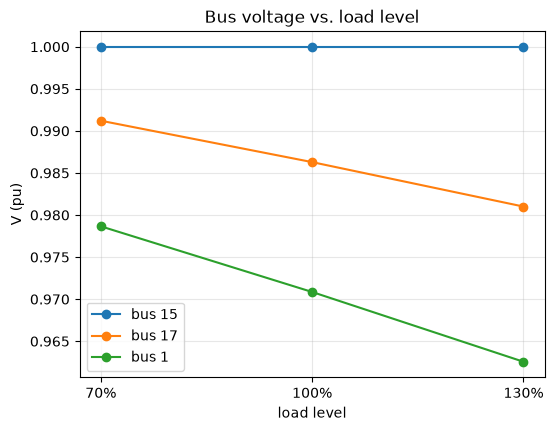

In [23]:
from g2elin_core.timeseries.scenario import scale_loads, run_time_series

snapshots = scale_loads(net, {"70%": 0.7, "100%": 1.0, "130%": 1.3})
ts = run_time_series(net, snapshots)
print("all converged:", ts.all_converged())

watch_buses = [15, 17, 1]  # SM terminal, GFL terminal, the feeder's heaviest load bus
fig, ax = plt.subplots(figsize=(6, 4.5))
for b in watch_buses:
    vals = [ts.bus_tables[snap.label].set_index("bus").loc[b, "vm_pu"] for snap in snapshots]
    ax.plot([s.label for s in snapshots], vals, marker="o", label=f"bus {b}")
ax.set_ylabel("V (pu)"); ax.set_xlabel("load level")
ax.set_title("Bus voltage vs. load level")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

Voltage droops with load at every bus, as expected, but not by the same
amount everywhere — the GFL's own terminal (bus 17, fixed $P/Q$
dispatch, no voltage control of its own) moves more with load than the
SM's slack terminal (bus 15, whose AVR is actively holding voltage), a
direct, visible consequence of the same "who's actually regulating
voltage here" question Section 1 raised in the abstract.

## Summary

| Module | What it told us about this network |
|---|---|
| `network` (schema/presets/topology) | The DER mix, dispatch, and physical layout |
| `powerflow` | A feasible, in-range voltage profile; the SM slack supplies ~2.27 MW (vs. the GFM/GFL's fixed 2.5 MW each) to balance the feeder's ~7.24 MW total load plus losses, from `ext_grid_table()` |
| `pu_base` | Two independent per-unit bases (20 kV feeder, 10 kV DER terminals) sharing one MVA base |
| `operating_point` | Three different ways of finding "the angle": rotor-angle geometry (SM), self-clocked droop angle (GFM), PLL-locked angle (GFL) |
| `components` (isolated) | 19/15/14 states for SM/GFM/GFL respectively, and how differently stiff each one's own open-loop dynamics are |
| `interconnect`/`pipeline` | A 48-state DER core plus 28+26+26 states from 14 nodes/13 lines/13 loads -- 128 states total for this 14-bus, 3-DER network |
| `modal` | Every mode stable except one structurally-zero reference-angle mode (the "theta problem," not a real instability); the genuine SM swing mode sits at ~2.2 Hz, ~22% damping |
| `modal.toolbox` | Mode shape, closed-form free response, and step response -- all from the same eigendecomposition, no extra solve |
| `timedomain` (EMT) | The nonlinear transient the linearization is only ever a small-signal approximation of |
| `stability` (ROA) | A local neighborhood of stable recovery around the operating point, consistent with the modal result |
| `timeseries` | Which bus's voltage is most exposed to load swings, and why (whose control loop is actually holding it) |

See `notebooks/tour.ipynb` for the same modules exercised more briefly
across several different presets, and `docs/sphinx/` for every equation
behind every number computed above.